<a href="https://colab.research.google.com/github/EdgarPrueba/Portafolio1/blob/main/NB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 4 — Estimación de Canal OFDM mediante Aprendizaje Automático

## 1. Introducción

En un sistema OFDM, la señal recibida se ve afectada por las características del canal de propagación y por el ruido. El modelo simplificado puede expresarse como

$$
Y = HX + N
$$

donde $X$ representa la señal transmitida, $H$ la respuesta del canal, $N$ el ruido y $Y$ la señal recibida.

La estimación de canal busca obtener una aproximación $\hat{H}$ a partir de las observaciones disponibles. Esta información es necesaria para compensar los efectos del canal durante la recepción.

En este notebook se estudia si un modelo pequeño de aprendizaje automático puede mejorar la estimación de la respuesta del canal a partir de una estimación imperfecta obtenida mediante LS e interpolación. El desempeño se analizará mediante el error cuadrático medio normalizado (NMSE) para diferentes niveles de SNR.

La comparación principal será entre un estimador clásico LS/interpolado y un modelo MLP implementado en PyTorch. El análisis se centrará en la relación entre la calidad de la observación, representada por la SNR, y la precisión de la estimación del canal.

# 1. Configuración, descarga e inspección del dataset

En esta sección se configura el entorno reproducible del experimento y se establecen las semillas aleatorias utilizadas por NumPy y PyTorch.

Se utiliza el dataset **ChanEst Dataset**, orientado a la estimación de canales inalámbricos mediante aprendizaje automático. Los archivos se descargan temporalmente en el entorno de ejecución de Colab, sin almacenarlos permanentemente en Google Drive.

El conjunto contiene observaciones de canales OFDM representadas mediante dos componentes, correspondientes a las partes real e imaginaria de la respuesta del canal.

Para el experimento se utilizarán las variables `X_input` y `Y_label`:

- `X_input`: estimación imperfecta del canal obtenida a partir de las observaciones recibidas.
- `Y_label`: referencia del canal ideal utilizada como objetivo de estimación.

La estructura de los datos es:

$$
( N,\ 2,\ 14,\ 612 )
$$

donde $N$ representa el número de muestras, las dos componentes corresponden a la representación real/imaginaria y las dimensiones restantes representan la estructura del canal OFDM.

También se verifica la estructura del archivo HDF5 y el rango de SNR disponible.

In [ ]:
# ==========================================
# CELDA 1: Configuración, descarga e inspección
# ==========================================

import os
import random
import h5py
import numpy as np
import pandas as pd
import torch

# -----------------------------
# Reproducibilidad
# -----------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"PyTorch: {torch.__version__}")
print(f"Dispositivo: {DEVICE}")

# -----------------------------
# Archivos del dataset
# -----------------------------

METADATA_FILENAME = (
    "6G_ChanEst_metadata_10k_samples.xlsx"
)

H5_FILENAME = (
    "6G_ChanEst_Dataset_10k_Samples.h5"
)

METADATA_URL = (
    "https://data.mendeley.com/datasets/8w3zjj8hzc/1/"
    "files/3dc1e282-ef83-499a-aa31-d436250e39dd/"
    "file_downloaded"
)

H5_URL = (
    "https://data.mendeley.com/datasets/8w3zjj8hzc/1/"
    "files/a1311583-cc5d-4a6f-ab91-583b4a8f73d5/"
    "file_downloaded"
)

# -----------------------------
# Descarga temporal
# -----------------------------

if not os.path.exists(METADATA_FILENAME):
    print("\nDescargando metadata...")
    !curl -L -s -H "User-Agent: Mozilla/5.0" "{METADATA_URL}" -o "{METADATA_FILENAME}"

if not os.path.exists(H5_FILENAME):
    print("Descargando dataset HDF5...")
    !curl -L -s -H "User-Agent: Mozilla/5.0" "{H5_URL}" -o "{H5_FILENAME}"

# -----------------------------
# Inspección del metadata
# -----------------------------

df_meta = pd.read_excel(METADATA_FILENAME)

print("\nDataset cargado correctamente.")
print(f"Muestras disponibles: {len(df_meta)}")

print("\nColumnas:")
print(df_meta.columns.tolist())

print("\nRango de SNR:")
print(
    f"{df_meta['SNR(dB)'].min():.2f} a "
    f"{df_meta['SNR(dB)'].max():.2f} dB"
)

# -----------------------------
# Inspección de HDF5
# -----------------------------

with h5py.File(H5_FILENAME, "r") as h5_file:
    print("\nEstructura principal:")
    print("X_input :", h5_file["X_input"].shape)
    print("Y_label :", h5_file["Y_label"].shape)

PyTorch: 2.11.0+cpu
Dispositivo: cpu

Dataset cargado correctamente.
Muestras disponibles: 10000

Columnas:
['Idx', 'Corr', 'MSE(lin)', 'MSE(dB)', 'NMSE(lin)', 'NMSE(dB)', 'SNR(dB)', 'DS(ns)', 'fd(Hz)', 'v(mps)', 'Pin(dB)', 'Pgt(dB)']

Rango de SNR:
-10.00 a 30.00 dB

Estructura principal:
X_input : (10000, 2, 14, 612)
Y_label : (10000, 2, 14, 612)


# 2. Selección y preparación de los datos

Para mantener un experimento controlado y computacionalmente manejable, se seleccionan únicamente muestras correspondientes al escenario **SISO con perfil de canal TDL-A**.

Se establecen siete condiciones de SNR:

$$
SNR \in \{-5,\ 0,\ 5,\ 10,\ 15,\ 20,\ 25\}\ \text{dB}
$$

Para cada condición se seleccionan 100 muestras cercanas al SNR objetivo, obteniendo un total de 700 muestras.

Posteriormente, los datos se dividen de forma estratificada en:

- 80 % para entrenamiento.
- 20 % para prueba.

De esta manera se mantienen 80 muestras de entrenamiento y 20 muestras de prueba para cada condición de SNR.

Finalmente, cada muestra se transforma de su representación original $(2,14,612)$ a un vector de 17 136 características para facilitar el procesamiento mediante aprendizaje automático.

In [ ]:
# ==========================================
# CELDA 2: Selección y preparación
# ==========================================

from sklearn.model_selection import train_test_split

TARGET_SNR = np.array([
    -5, 0, 5, 10, 15, 20, 25
])

SAMPLES_PER_SNR = 100
TEST_SIZE = 0.20

SISO_CODE = np.array([83, 73, 83, 79])
TDL_A_CODE = 65

# -----------------------------
# Leer logs necesarios
# -----------------------------

with h5py.File(H5_FILENAME, "r") as h5_file:

    snr_log = np.asarray(
        h5_file["logs/snrLog_dB"]
    ).reshape(-1)

    profile_log = np.asarray(
        h5_file["logs/profileLog"]
    )

    mimo_corr_log = np.asarray(
        h5_file["logs/mimoCorrLog"]
    )

# -----------------------------
# Filtrar SISO + TDL-A
# -----------------------------

siso_mask = np.all(
    mimo_corr_log.T == SISO_CODE,
    axis=1
)

tdl_a_mask = (
    (profile_log[0] == 84) &
    (profile_log[1] == 68) &
    (profile_log[2] == 76) &
    (profile_log[3] == 45) &
    (profile_log[4] == TDL_A_CODE)
)

valid_indices = np.where(
    siso_mask & tdl_a_mask
)[0]

print(
    f"Muestras SISO + TDL-A: "
    f"{len(valid_indices)}"
)

# -----------------------------
# Seleccionar muestras por SNR
# -----------------------------

selected_indices = []
selected_snr = []
selected_snr_group = []

for target in TARGET_SNR:

    distances = np.abs(
        snr_log[valid_indices] - target
    )

    ordered = valid_indices[
        np.argsort(distances)
    ]

    chosen = ordered[:SAMPLES_PER_SNR]

    selected_indices.extend(chosen)
    selected_snr.extend(snr_log[chosen])
    selected_snr_group.extend(
        np.full(SAMPLES_PER_SNR, target)
    )

selected_indices = np.asarray(
    selected_indices,
    dtype=int
)

selected_snr = np.asarray(
    selected_snr,
    dtype=np.float32
)

selected_snr_group = np.asarray(
    selected_snr_group,
    dtype=np.float32
)

# -----------------------------
# Cargar subconjunto
# -----------------------------

sort_order = np.argsort(selected_indices)

sorted_indices = selected_indices[
    sort_order
]

with h5py.File(H5_FILENAME, "r") as h5_file:

    X_sorted = np.asarray(
        h5_file["X_input"][sorted_indices],
        dtype=np.float32
    )

    Y_sorted = np.asarray(
        h5_file["Y_label"][sorted_indices],
        dtype=np.float32
    )

inverse_order = np.argsort(sort_order)

X_input = X_sorted[inverse_order]
Y_label = Y_sorted[inverse_order]

# -----------------------------
# División estratificada
# -----------------------------

indices = np.arange(
    len(X_input)
)

train_idx, test_idx = train_test_split(
    indices,
    test_size=TEST_SIZE,
    random_state=SEED,
    shuffle=True,
    stratify=selected_snr_group
)

X_train = X_input[train_idx]
X_test = X_input[test_idx]

Y_train = Y_label[train_idx]
Y_test = Y_label[test_idx]

snr_test = selected_snr[test_idx]
snr_group_test = selected_snr_group[test_idx]

# -----------------------------
# Aplanar canal
# -----------------------------

X_train_flat = X_train.reshape(
    len(X_train), -1
)

X_test_flat = X_test.reshape(
    len(X_test), -1
)

Y_train_flat = Y_train.reshape(
    len(Y_train), -1
)

Y_test_flat = Y_test.reshape(
    len(Y_test), -1
)

print("\nSubconjunto:")
print("X:", X_input.shape)
print("Y:", Y_label.shape)

print("\nPartición:")
print(f"Train: {len(X_train)}")
print(f"Test : {len(X_test)}")

print("\nRepresentación aplanada:")
print("Entrada:", X_train_flat.shape)
print("Salida :", Y_train_flat.shape)

Muestras SISO + TDL-A: 2000

Subconjunto:
X: (700, 2, 14, 612)
Y: (700, 2, 14, 612)

Partición:
Train: 560
Test : 140

Representación aplanada:
Entrada: (560, 17136)
Salida : (560, 17136)


# 3. Baseline convencional y representación mediante PCA

Como referencia se utiliza `X_input` directamente como una estimación convencional del canal. El error se calcula respecto a `Y_label`, considerado como la referencia del canal real.

El desempeño se evalúa mediante el **Normalized Mean Squared Error (NMSE)**:

$$
NMSE =
\frac{\|Y-\hat{Y}\|_2^2}
{\|Y\|_2^2}
$$

y su representación en decibelios:

$$
NMSE_{dB}=10\log_{10}(NMSE)
$$

Este baseline permite establecer una referencia contra la cual comparar el modelo de aprendizaje automático.

Debido a que cada canal contiene 17 136 valores, se utiliza **Análisis de Componentes Principales (PCA)** para obtener una representación compacta de 128 componentes.

El PCA se ajusta exclusivamente utilizando los datos de entrenamiento de `Y_label`, evitando utilizar información del conjunto de prueba durante el ajuste.

Los 128 componentes explican aproximadamente el **83.15 % de la varianza** presente en los canales de entrenamiento.

Tanto `X_input` como `Y_label` se proyectan posteriormente sobre esta misma base de componentes principales.

In [ ]:
# ==========================================
# CELDA 3: Baseline y reducción PCA
# ==========================================

from sklearn.decomposition import PCA

# -----------------------------
# Validación de escala
# -----------------------------

print("Potencia media:")

print(
    f"X_input: {np.mean(X_input**2):.6e}"
)

print(
    f"Y_label: {np.mean(Y_label**2):.6e}"
)

# -----------------------------
# Baseline LS/interpolado
# -----------------------------

error_baseline = (
    Y_test_flat - X_test_flat
)

nmse_baseline = (
    np.sum(error_baseline ** 2, axis=1)
    /
    np.sum(Y_test_flat ** 2, axis=1)
)

baseline_nmse = np.mean(
    nmse_baseline
)

baseline_db = 10 * np.log10(
    baseline_nmse
)

print("\nBaseline LS/interpolado:")
print(
    f"NMSE = {baseline_nmse:.6f}"
)

print(
    f"NMSE(dB) = {baseline_db:.3f} dB"
)

# -----------------------------
# PCA sobre Y_train
# -----------------------------

PCA_COMPONENTS = 128

pca_channel = PCA(
    n_components=PCA_COMPONENTS,
    svd_solver="randomized",
    random_state=SEED
)

pca_channel.fit(Y_train_flat)

# Proyección común de entrada y referencia
X_train_pca = pca_channel.transform(
    X_train_flat
)

X_test_pca = pca_channel.transform(
    X_test_flat
)

Y_train_pca = pca_channel.transform(
    Y_train_flat
)

Y_test_pca = pca_channel.transform(
    Y_test_flat
)

explained_variance = np.sum(
    pca_channel.explained_variance_ratio_
)

print("\nRepresentación PCA:")
print("X_train:", X_train_pca.shape)
print("X_test :", X_test_pca.shape)
print("Y_train:", Y_train_pca.shape)
print("Y_test :", Y_test_pca.shape)

print(
    f"Varianza explicada: "
    f"{explained_variance * 100:.2f}%"
)

Potencia media:
X_input: 4.300573e-01
Y_label: 4.765571e-01

Baseline LS/interpolado:
NMSE = 0.581362
NMSE(dB) = -2.356 dB

Representación PCA:
X_train: (560, 128)
X_test : (140, 128)
Y_train: (560, 128)
Y_test : (140, 128)
Varianza explicada: 83.15%


# 4. Estimación del canal mediante MLP residual

En lugar de intentar aprender directamente el canal completo, el modelo aprende la **corrección residual** necesaria para transformar la estimación inicial en una aproximación más cercana al canal de referencia.

El residual se define como:

$$
R = Y_{PCA}-X_{PCA}
$$

El modelo aprende entonces:

$$
\hat{R}=f_{\theta}(X_{PCA})
$$

y la estimación final en el espacio PCA se obtiene mediante:

$$
\hat{Y}_{PCA}=X_{PCA}+\hat{R}
$$

La arquitectura utilizada es un MLP compacto:

$$
128 \rightarrow 64 \rightarrow 128
$$

con funciones de activación ReLU.

El modelo contiene **16 576 parámetros entrenables** y se optimiza mediante Adam con una tasa de aprendizaje de $10^{-3}$ durante 50 épocas.

Finalmente, la estimación obtenida en el espacio PCA se transforma nuevamente al espacio original mediante la transformación inversa del PCA.

In [ ]:
# ==========================================
# CELDA 4: Entrenamiento e inferencia
# ==========================================

import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

EPOCHS = 50
BATCH_SIZE = 32

# -----------------------------
# Residuo a aprender
# -----------------------------

R_train_pca = (
    Y_train_pca - X_train_pca
)

# -----------------------------
# Tensores
# -----------------------------

X_train_pca_tensor = torch.tensor(
    X_train_pca,
    dtype=torch.float32,
    device=DEVICE
)

X_test_pca_tensor = torch.tensor(
    X_test_pca,
    dtype=torch.float32,
    device=DEVICE
)

R_train_tensor = torch.tensor(
    R_train_pca,
    dtype=torch.float32,
    device=DEVICE
)

# -----------------------------
# Modelo residual
# -----------------------------

class ResidualChannelEstimator(nn.Module):

    def __init__(
        self,
        input_dim=128,
        hidden_dim=64,
        output_dim=128
    ):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.network(x)


model_pca = ResidualChannelEstimator(
    input_dim=PCA_COMPONENTS,
    hidden_dim=64,
    output_dim=PCA_COMPONENTS
).to(DEVICE)

# -----------------------------
# Entrenamiento
# -----------------------------

train_dataset = TensorDataset(
    X_train_pca_tensor,
    R_train_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model_pca.parameters(),
    lr=1e-3
)

num_parameters = sum(
    p.numel()
    for p in model_pca.parameters()
    if p.requires_grad
)

print(
    f"Parámetros entrenables: "
    f"{num_parameters:,}"
)

print("\nEntrenamiento:")

model_pca.train()

for epoch in range(EPOCHS):

    epoch_loss = 0.0

    for X_batch, R_batch in train_loader:

        optimizer.zero_grad()

        R_pred = model_pca(X_batch)

        loss = criterion(
            R_pred,
            R_batch
        )

        loss.backward()
        optimizer.step()

        epoch_loss += (
            loss.item() *
            X_batch.size(0)
        )

    epoch_loss /= len(train_dataset)

    if epoch == 0 or (epoch + 1) % 10 == 0:

        print(
            f"Época {epoch + 1:02d}/{EPOCHS} "
            f"- Loss: {epoch_loss:.6e}"
        )

# -----------------------------
# Inferencia
# -----------------------------

model_pca.eval()

with torch.no_grad():

    R_pred_pca = model_pca(
        X_test_pca_tensor
    ).cpu().numpy()

# Corrección residual
Y_pred_pca = (
    X_test_pca + R_pred_pca
)

# Regresar al dominio original
Y_pred_flat = (
    pca_channel.inverse_transform(
        Y_pred_pca
    )
)

print("\nEstimación reconstruida:")
print(Y_pred_flat.shape)

Parámetros entrenables: 16,576

Entrenamiento:
Época 01/50 - Loss: 1.519748e+01
Época 10/50 - Loss: 1.217970e+01
Época 20/50 - Loss: 1.071269e+01
Época 30/50 - Loss: 9.651760e+00
Época 40/50 - Loss: 8.912979e+00
Época 50/50 - Loss: 8.389706e+00

Estimación reconstruida:
(140, 17136)


# 5. Evaluación del modelo y comparación de desempeño

El desempeño del MLP residual se compara con el baseline utilizando el NMSE sobre el conjunto de prueba.

Además del resultado global, se calcula el NMSE para cada una de las siete condiciones de SNR.

La mejora relativa respecto al baseline se calcula mediante:

$$
Mejora =
\left(
1-\frac{NMSE_{MLP}}{NMSE_{baseline}}
\right)\times100
$$

Finalmente, se representa el NMSE en función del SNR para observar cómo cambia el desempeño de ambos métodos según las condiciones del canal.

Esta comparación permite determinar si el aprendizaje automático proporciona una ventaja respecto a la estimación convencional y en qué condiciones de SNR dicha ventaja resulta más significativa.

========== RESULTADOS GLOBALES ==========
Baseline LS/interpolado : 0.581362 (-2.356 dB)
MLP residual            : 0.569101 (-2.448 dB)
Mejora relativa         : 2.11 %

========== RESULTADOS POR SNR ==========
SNR  -5 dB | Baseline:   1.720 dB | MLP:  -0.624 dB
SNR   0 dB | Baseline:  -2.342 dB | MLP:  -2.556 dB
SNR   5 dB | Baseline:  -2.748 dB | MLP:  -2.111 dB
SNR  10 dB | Baseline:  -4.682 dB | MLP:  -3.417 dB
SNR  15 dB | Baseline:  -3.951 dB | MLP:  -2.891 dB
SNR  20 dB | Baseline:  -3.610 dB | MLP:  -2.501 dB
SNR  25 dB | Baseline:  -5.364 dB | MLP:  -3.809 dB


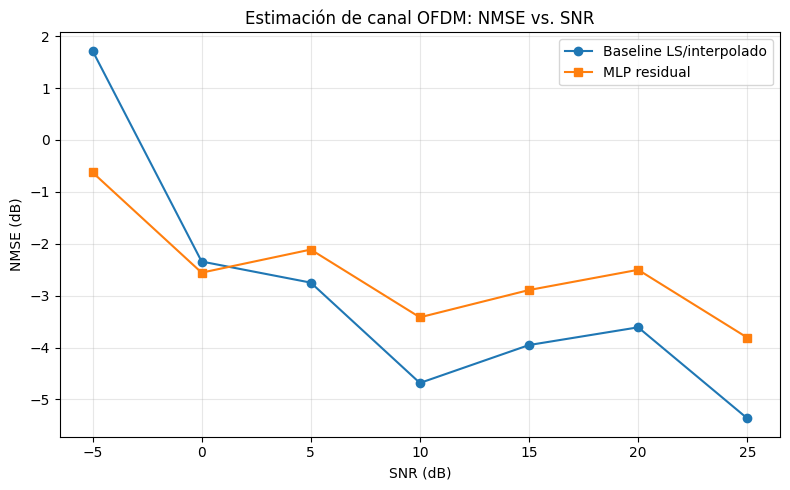

In [ ]:
# ==========================================
# CELDA 5: Evaluación y NMSE vs. SNR
# ==========================================

import matplotlib.pyplot as plt

# -----------------------------
# NMSE del MLP residual
# -----------------------------

error_mlp = (
    Y_test_flat - Y_pred_flat
)

nmse_mlp = (
    np.sum(error_mlp ** 2, axis=1)
    /
    np.sum(Y_test_flat ** 2, axis=1)
)

# -----------------------------
# Resultados globales
# -----------------------------

mlp_nmse = np.mean(nmse_mlp)

mlp_db = 10 * np.log10(
    mlp_nmse
)

improvement = (
    1 -
    mlp_nmse / baseline_nmse
) * 100

print("========== RESULTADOS GLOBALES ==========")

print(
    f"Baseline LS/interpolado : "
    f"{baseline_nmse:.6f} "
    f"({baseline_db:.3f} dB)"
)

print(
    f"MLP residual            : "
    f"{mlp_nmse:.6f} "
    f"({mlp_db:.3f} dB)"
)

print(
    f"Mejora relativa         : "
    f"{improvement:.2f} %"
)

# -----------------------------
# Resultados por SNR
# -----------------------------

baseline_snr_db = []
mlp_snr_db = []

print("\n========== RESULTADOS POR SNR ==========")

for target in TARGET_SNR:

    mask = (
        snr_group_test == target
    )

    baseline_group = np.mean(
        nmse_baseline[mask]
    )

    mlp_group = np.mean(
        nmse_mlp[mask]
    )

    baseline_group_db = (
        10 * np.log10(baseline_group)
    )

    mlp_group_db = (
        10 * np.log10(mlp_group)
    )

    baseline_snr_db.append(
        baseline_group_db
    )

    mlp_snr_db.append(
        mlp_group_db
    )

    print(
        f"SNR {target:>3} dB | "
        f"Baseline: {baseline_group_db:>7.3f} dB | "
        f"MLP: {mlp_group_db:>7.3f} dB"
    )

# -----------------------------
# Gráfica principal
# -----------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    TARGET_SNR,
    baseline_snr_db,
    marker="o",
    label="Baseline LS/interpolado"
)

plt.plot(
    TARGET_SNR,
    mlp_snr_db,
    marker="s",
    label="MLP residual"
)

plt.xlabel("SNR (dB)")
plt.ylabel("NMSE (dB)")
plt.title(
    "Estimación de canal OFDM: NMSE vs. SNR"
)

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 6. Perfil del error por componente principal

Para complementar la comparación global de NMSE, se analiza la distribución del error de estimación en el espacio reducido obtenido mediante PCA.

Se seleccionan las muestras del conjunto de prueba correspondientes a:

$$
SNR=0\text{ dB}
$$

Para cada uno de los 128 componentes principales se calcula el error cuadrático medio entre la estimación y el canal de referencia.

Se comparan:

- el error del baseline LS/interpolado respecto a `Y_test_pca`;
- el error de la estimación MLP residual respecto a `Y_test_pca`.

Esta representación permite identificar en qué componentes de la representación reducida se concentra el error y si el modelo residual logra reducirlo respecto a la estimación inicial.

La figura complementa la curva de NMSE vs. SNR al proporcionar una visión más detallada del comportamiento del modelo dentro del espacio de características utilizado para el aprendizaje.

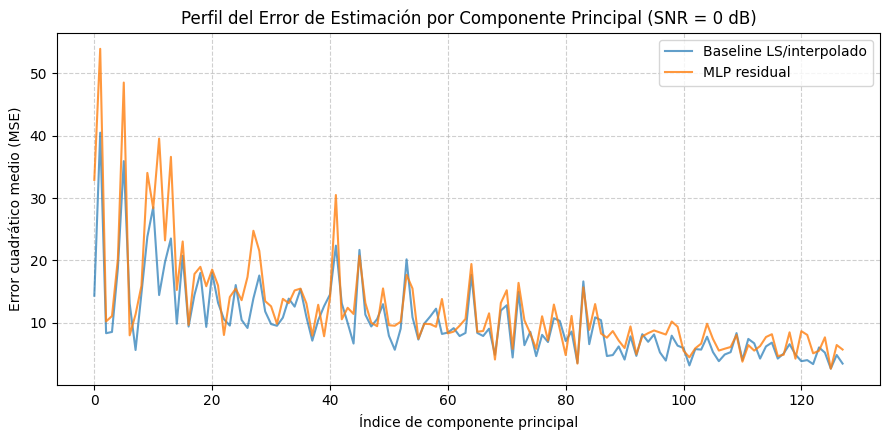

In [ ]:
# ==========================================
# CELDA 6: Perfil del Error por Componente Principal
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

# Seleccionar muestras de prueba del grupo SNR = 0 dB
mask_0db = snr_group_test == 0

# MSE por componente principal en el espacio PCA
mse_baseline_pca = np.mean(
    (X_test_pca[mask_0db] - Y_test_pca[mask_0db])**2,
    axis=0
)

mse_mlp_pca = np.mean(
    (Y_pred_pca[mask_0db] - Y_test_pca[mask_0db])**2,
    axis=0
)

plt.figure(figsize=(9, 4.5))

plt.plot(
    mse_baseline_pca,
    label="Baseline LS/interpolado",
    alpha=0.7
)

plt.plot(
    mse_mlp_pca,
    label="MLP residual",
    alpha=0.8
)

plt.title(
    "Perfil del Error de Estimación por Componente Principal (SNR = 0 dB)"
)

plt.xlabel("Índice de componente principal")
plt.ylabel("Error cuadrático medio (MSE)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.savefig(
    "error_per_pca_component_0db.png",
    dpi=300
)

plt.show()

# 7. Comparación de la respuesta del canal OFDM

Para complementar la comparación cuantitativa del NMSE, se visualiza la respuesta estimada de una muestra del conjunto de prueba correspondiente al grupo de **SNR = 0 dB**.

Se comparan tres representaciones:

- **Canal real:** referencia `Y_label`.
- **Baseline LS/interpolado:** estimación inicial `X_input`.
- **MLP residual:** estimación reconstruida por el modelo.

La representación compleja del canal se obtiene a partir de sus componentes real e imaginaria:

$$
H = H_{Re}+jH_{Im}
$$

y se utiliza la magnitud de la respuesta:

$$
|H|=\sqrt{H_{Re}^{2}+H_{Im}^{2}}
$$

La magnitud se promedia sobre las 14 posiciones disponibles para obtener una representación de la respuesta del canal a lo largo de las 612 subportadoras.

Esta figura permite complementar el análisis de NMSE con una interpretación física, observando directamente qué tan cercana es cada estimación a la respuesta del canal de referencia.

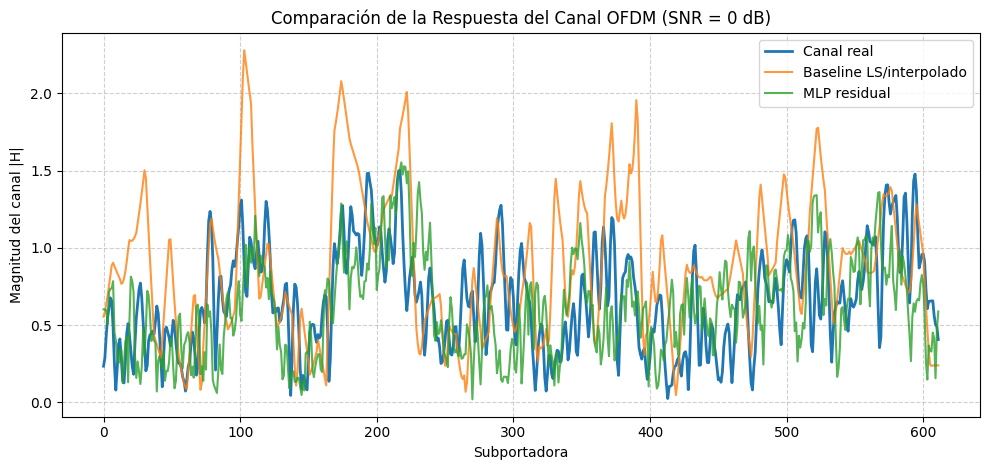

In [ ]:
# ==========================================
# CELDA 7: Comparación de la Respuesta del Canal
# SNR ≈ 0 dB
# ==========================================

import matplotlib.pyplot as plt
import numpy as np

# Seleccionar una muestra de prueba a 0 dB
idx_0db = np.where(snr_group_test == 0)[0][0]

# Recuperar la muestra original (2, 14, 612)
H_real = Y_test[idx_0db]
H_baseline = X_test[idx_0db]
H_mlp = Y_pred_flat[idx_0db].reshape(2, 14, 612)

# Reconstruir el canal complejo
H_real_complex = H_real[0] + 1j * H_real[1]
H_baseline_complex = H_baseline[0] + 1j * H_baseline[1]
H_mlp_complex = H_mlp[0] + 1j * H_mlp[1]

# Seleccionar una posición del canal
position = 0

# Magnitud del canal en las 612 subportadoras
H_real_mag = np.abs(H_real_complex[position])
H_baseline_mag = np.abs(H_baseline_complex[position])
H_mlp_mag = np.abs(H_mlp_complex[position])

# Graficar
plt.figure(figsize=(10, 4.8))

plt.plot(
    H_real_mag,
    label="Canal real",
    linewidth=2
)

plt.plot(
    H_baseline_mag,
    label="Baseline LS/interpolado",
    alpha=0.8
)

plt.plot(
    H_mlp_mag,
    label="MLP residual",
    alpha=0.8
)

plt.title("Comparación de la Respuesta del Canal OFDM (SNR = 0 dB)")
plt.xlabel("Subportadora")
plt.ylabel("Magnitud del canal |H|")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()

plt.savefig(
    "comparacion_canal_ofdm_0db.png",
    dpi=300
)

plt.show()